# Lab 8 Report: 
## FINAL PROJECT STRATEGIC PLANNING

### Lab 8 Instruction: 
https://canvas.uw.edu/files/106242897/download?download_frd=1

### Team Members: Madison Ringham, Sean Kawano

### Dataset for your project: SDSS17 Stellar Classification Dataset

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [18]:
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

---

## Understanding the Data

* how big is the data? √
* how is it structured? √
* are there any obvious patterns? are these patterns expeected? √
* Are there any unusual features?
* What will we do if the data is corrupted?
* What about if data is mislabeled? --> account for NaNs!
* if the data is simulated, does it have limitations? --> this doesn't apply to our project
* how many features are there per data sample? √
* does the dataset have an equal number of datapoints per label? --> it should! check if every entry has valid points for the features we're considering

In [2]:
# data size
data = pd.read_csv("star_classification.csv")
print(f'The dataset includes {len(data)} observations, including stars, galaxies, and quasars')

The dataset includes 100000 observations, including stars, galaxies, and quasars


In [3]:
# data structure

print(f'Number of features per observation:{len(data.keys())}')
print(f'Features in the data for each observation{data.columns.tolist()}')

Number of features per observation:18
Features in the data for each observation['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


The dataset we're using, the SDSS17 Stellar Classification Dataset, includes 100,000 observations each with 18 features. Each observation has one value per feature. One of the features, "class" lists the object type (star, galaxy, or quasar). The data is organized in a single .csv file, with each row representing a single observation, and each column representing the features associated with that observation.

In [4]:
# data patterns

def k_means_clustering(data, cluster_size):
    kmeans = KMeans(n_clusters=cluster_size, random_state=42).fit(data)
    centroids = kmeans.cluster_centers_
    rep_id = pairwise_distances_argmin(centroids, data)
    clustering = data[rep_id]
    return clustering

feature_list = ["u","g","r","i","z","redshift","alpha","delta","MJD"]

# setting the class labels: galaxies = 0, quasars = 1, stars = 2
label_dict = {"GALAXY":0,"QSO":1,"STAR":2}

# not including the scaling at first
#scaler = StandardScaler()
#data[feature_list] = scaler.fit_transform(data[feature_list])
#threshold = 5
#data = data[~ (data[feature_list]**2 > threshold**2).any(axis=1)]

for feature in data[feature_list].columns:
    mean = data[feature].mean()
    std = data[feature].std()
    d = data[abs(data[feature] - mean) <= 5 * std]

#data = data.sample(100000)

X = data[feature_list].to_numpy()
y = data["class"].replace(label_dict).to_numpy()

galaxies = data[data["class"] == "GALAXY"][feature_list]
quasars = data[data["class"] == "QSO"][feature_list]
stars = data[data["class"] == "STAR" ][feature_list]

galaxies_np = galaxies.to_numpy()
quasars_np = quasars.to_numpy()
stars_np = stars.to_numpy()

print(f"number of galaxies: {len(galaxies_np)}")
print(f"number of quasar: {len(quasars_np)}")
print(f"number of stars: {len(stars_np)}")
galaxy_sample = k_means_clustering(galaxies_np, 30)
quasar_sample = k_means_clustering(quasars_np, 30)
stars_sample = k_means_clustering(stars_np, 30)

clusters = [galaxy_sample,quasar_sample,stars_sample]

/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_10745/636647280.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = data["class"].replace(label_dict).to_numpy()


number of galaxies: 59445
number of quasar: 18961
number of stars: 21594


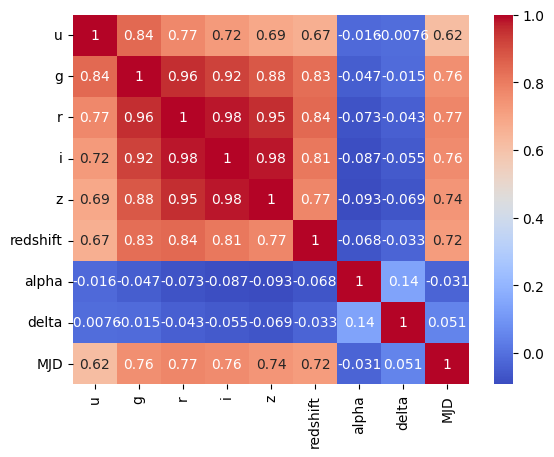

In [5]:
# making a correlation matrix
sns.heatmap(galaxies.corr(), annot=True, cmap='coolwarm')

plt.show()

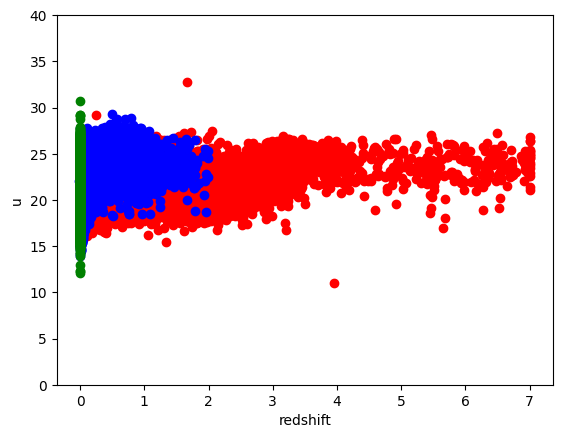

In [9]:
# expected patterns: redshift difference between classes

plt.scatter(np.array(quasars['redshift']), np.array(quasars['u']),color='r')
plt.scatter(np.array(galaxies['redshift']), np.array(galaxies['u']),color='b')
plt.scatter(np.array(stars['redshift']), np.array(stars['u']),color='g')

plt.ylim(0,40)
plt.xlabel('redshift')
plt.ylabel('u');

Looking at the differences in redshift between classes in the dataset, these values are expected. Redshift is an indicator of how far away an object is from Earth, as well as whether an object is moving towards or away from our galaxy and how fast. Objects that are farther away are moving away from us much faster. In general terms, we'll consider redshift as a distance indicator, where the larger the value indicates a greater distance. 

We expect stars to have a much lower redshift value (around zero), since stars we observe most likely originate from within the Milky Way galaxy. We also expect some stars to have a slightly negative redshift ('blueshift') indicating that the star is moving towards Earth.

Galaxies and quasars are much farther away, so they would have a greater redshift value. Quasars are much more luminous than galaxies, so we expect that observations in the dataset with large redshifts to be quasars. 

The above plot shows the expected redshifts: stars have redshift values around zero, galaxies span redshift 0-2, and quasars span redshifts 0-7.

In [31]:
labels = y*0.5
trace = go.Scatter3d(
    x=np.array(data['redshift']),
    y=np.array(data['u']),
    z=np.array(data['z']),
    mode='markers',
    marker=dict(
        size=2,
        color=y,
        colorscale='Viridis',
        opacity=0.5
    )
)

fig=go.Figure(data=[trace])

fig.update_layout(
    title='3D Scatter Plot',
    scene=dict(
        yaxis=dict(range=[5,35]),
        zaxis=dict(range=[5,35]),
        xaxis_title='Redshift',
        yaxis_title='u',
        zaxis_title='z'
    ),
    height=500,
    width=800
)

fig.show(renderer="browser")

## Understanding the Task

* what problem are you trying to solve with your neural network? (classification or regression)
* what is the significance of solving the problem?
* what is the evaluation metric of the neural network model?
* what would constitute as good performance?
* is there a baseline method to  compare against after meeting the performance? (classical ML method?)

Baseline models: train a simple MLP on the raw features, see if we get better performance than this. 

## Developing an initial plan for your project

* what are the inputs and outputs (with dimensions) of the model?
* what data preparation methods do we plan to use?
* what neural network model do you plan to use? (FCN, CNN, RNN)
* what loss function do you plan to use?
* how do you plan to evaluate your model?

The inputs to our neural net model will be three 20x20 images. We pick out the "u," "g", and "redshift," parameters to be the coordinates of the points in our dataset. We first apply normal scaling to each point in our original data and then remove any points that have entries greater than 4. Since we are applying standard scaling, this results in us removing values that were 4 standard deviations away from the mean. Then we use K-means sampling to select a representative sample of each category: Galaxy, Quasar, Star. Then for each point, we append it to the each sample and then compute a persistence image. We plan to use convolutional neural network with the standard cross entropy loss function for classification. Then we will evaluate this model by comparing the accuracy and confusion matrix with other baseline approaches. 